In [1]:
#Instalação de Pacotes, inclusive para imprimir gráficos
#Execute esta célula antes dos demais exemplos. A instalação precisa ser refeita sempre que uma nova sessão do. Google Colab for iniciada.

!pip install -q qiskit qiskit-aer pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.3 MB/s eta 0:00:00


In [2]:
from math import pi

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler


# ============================================================
# 1. CRIAÇÃO DO CIRCUITO E PARÂMETRO
# ============================================================

theta = Parameter("theta")

qc = QuantumCircuit(3)


# ============================================================
# 2. PREPARAÇÃO DOS QUBITS
# ============================================================

# q0: cria uma superposição
qc.h(0)

# q1: prepara o estado |1>
qc.x(1)

# q2: aplica uma rotação parametrizada
qc.ry(theta, 2)

qc.barrier()


# ============================================================
# 3. TRANSFORMAÇÕES
# ============================================================

# Altera a fase relativa de q0
qc.z(0)

# Rotação em torno do eixo X
qc.rx(pi / 2, 1)

# Rotação em torno do eixo Z
qc.rz(pi / 4, 2)

qc.barrier()


# ============================================================
# 4. OPERAÇÕES ENTRE QUBITS
# ============================================================

# Porta controlada:
# q0 = controle
# q1 = alvo
qc.cx(0, 1)

# Porta CZ entre q1 e q2
qc.cz(1, 2)

qc.barrier()


# ============================================================
# 5. ATRIBUIÇÃO DO VALOR AO PARÂMETRO
# ============================================================

# O mesmo circuito pode ser reutilizado com diferentes valores
# para theta, sem modificar sua estrutura.

qc_final = qc.assign_parameters({theta: pi / 3})


# ============================================================
# 6. INSPEÇÃO DO CIRCUITO
# ============================================================

print("\nCIRCUITO QUÂNTICO\n")

print(qc_final.draw())

print("\nProfundidade do circuito:")
print(qc_final.depth())

print("\nQuantidade de operações:")
print(qc_final.count_ops())


# Para visualizar graficamente no Jupyter:
# qc_final.draw("mpl")


# ============================================================
# 7. ESTADO QUÂNTICO ANTES DA MEDIÇÃO
# ============================================================

estado = Statevector.from_instruction(qc_final)

print("\nVETOR DE ESTADO\n")
print(estado)

print("\nPROBABILIDADES TEÓRICAS\n")

probabilidades = estado.probabilities_dict()

for bitstring, probabilidade in probabilidades.items():
    print(f"{bitstring}: {probabilidade:.4f}")


# ============================================================
# 8. CÓPIA DO CIRCUITO E MEDIÇÃO
# ============================================================

# Mantemos qc_final sem medição para poder analisar seu
# Statevector e criamos uma cópia destinada à execução.

qc_medido = qc_final.copy()

qc_medido.measure_all()

print("\nCIRCUITO COM MEDIÇÃO\n")

print(qc_medido.draw())

# Para visualizar graficamente:
# qc_medido.draw("mpl")


# ============================================================
# 9. EXECUÇÃO COM STATEVECTORSAMPLER
# ============================================================

sampler = StatevectorSampler()

shots = 1024

resultado = sampler.run(
    [qc_medido],
    shots=shots
).result()

contagens = resultado[0].data.meas.get_counts()


# ============================================================
# 10. RESULTADOS DAS MEDIÇÕES
# ============================================================

print("\nCONTAGENS OBTIDAS\n")

print(contagens)


# ============================================================
# 11. FREQUÊNCIAS RELATIVAS
# ============================================================

print("\nFREQUÊNCIAS RELATIVAS\n")

for bitstring, quantidade in sorted(contagens.items()):
    frequencia = quantidade / shots

    print(
        f"{bitstring}: "
        f"{quantidade:4d} ocorrências "
        f"-> frequência = {frequencia:.4f}"
    )


# ============================================================
# 12. COMPARAÇÃO ENTRE TEORIA E EXPERIMENTO
# ============================================================

print("\nCOMPARAÇÃO: PROBABILIDADE TEÓRICA × FREQUÊNCIA\n")

todos_resultados = sorted(
    set(probabilidades.keys()) | set(contagens.keys())
)

for bitstring in todos_resultados:

    probabilidade = probabilidades.get(bitstring, 0)

    quantidade = contagens.get(bitstring, 0)

    frequencia = quantidade / shots

    print(
        f"{bitstring}: "
        f"probabilidade teórica = {probabilidade:.4f} | "
        f"frequência observada = {frequencia:.4f}"
    )


CIRCUITO QUÂNTICO

        ┌───┐    ░    ┌───┐    ░          ░ 
q_0: ───┤ H ├────░────┤ Z ├────░───■──────░─
        ├───┤    ░ ┌──┴───┴──┐ ░ ┌─┴─┐    ░ 
q_1: ───┤ X ├────░─┤ Rx(π/2) ├─░─┤ X ├─■──░─
     ┌──┴───┴──┐ ░ ├─────────┤ ░ └───┘ │  ░ 
q_2: ┤ Ry(π/3) ├─░─┤ Rz(π/4) ├─░───────■──░─
     └─────────┘ ░ └─────────┘ ░          ░ 

Profundidade do circuito:
4

Quantidade de operações:
OrderedDict({'barrier': 3, 'h': 1, 'x': 1, 'ry': 1, 'z': 1, 'rx': 1, 'rz': 1, 'cx': 1, 'cz': 1})

VETOR DE ESTADO

Statevector([-0.16570679-0.40005157j, -0.40005157+0.16570679j,
              0.40005157-0.16570679j,  0.16570679+0.40005157j,
              0.09567086-0.23096988j, -0.23096988-0.09567086j,
             -0.23096988-0.09567086j,  0.09567086-0.23096988j],
            dims=(2, 2, 2))

PROBABILIDADES TEÓRICAS

000: 0.1875
001: 0.1875
010: 0.1875
011: 0.1875
100: 0.0625
101: 0.0625
110: 0.0625
111: 0.0625

CIRCUITO COM MEDIÇÃO

           ┌───┐    ░    ┌───┐    ░          ░  ░ ┌─┐      
   q_0: ─

Profundidade: 4
Operações: OrderedDict({'barrier': 3, 'h': 1, 'x': 1, 'ry': 1, 'z': 1, 'rx': 1, 'rz': 1, 'cx': 1, 'cz': 1})


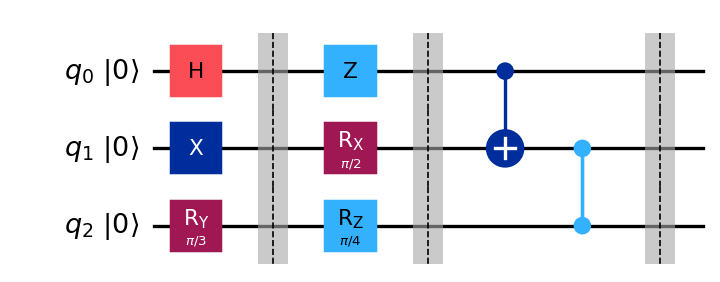

In [3]:
from math import pi

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler

import matplotlib.pyplot as plt


# ============================================================
# 1. CRIAÇÃO DO PARÂMETRO E DO CIRCUITO
# ============================================================

theta = Parameter("θ")

qc = QuantumCircuit(3)


# ============================================================
# 2. PREPARAÇÃO DOS QUBITS
# ============================================================

qc.h(0)          # q0: cria superposição
qc.x(1)          # q1: prepara |1>
qc.ry(theta, 2)  # q2: rotação parametrizada

qc.barrier()


# ============================================================
# 3. TRANSFORMAÇÕES
# ============================================================

qc.z(0)
qc.rx(pi / 2, 1)
qc.rz(pi / 4, 2)

qc.barrier()


# ============================================================
# 4. OPERAÇÕES ENTRE QUBITS
# ============================================================

qc.cx(0, 1)
qc.cz(1, 2)

qc.barrier()


# ============================================================
# 5. ATRIBUIÇÃO DO PARÂMETRO
# ============================================================

qc_final = qc.assign_parameters({theta: pi / 3})


# ============================================================
# 6. INFORMAÇÕES ESTRUTURAIS
# ============================================================

print("Profundidade:", qc_final.depth())
print("Operações:", qc_final.count_ops())


# ============================================================
# 7. VISUALIZAÇÃO DO CIRCUITO
# ============================================================

qc_final.draw(
    output="mpl",
    fold=-1,
    initial_state=True,
    idle_wires=False,
    scale=1.2
)

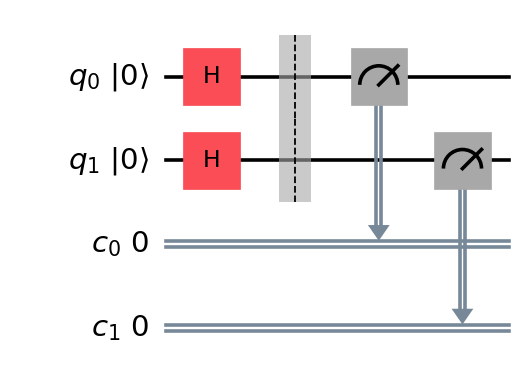

In [4]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


# ============================================================
# 1. CRIAÇÃO DO CIRCUITO
# ============================================================

# Dois qubits e dois bits clássicos
qc = QuantumCircuit(2, 2)


# ============================================================
# 2. PREPARAÇÃO DA SUPERPOSIÇÃO
# ============================================================

# Cada porta H transforma |0> em uma superposição
# dos estados |0> e |1>.

qc.h(0)
qc.h(1)

qc.barrier()


# ============================================================
# 3. MEDIÇÃO
# ============================================================

# Mede q0 e armazena o resultado em c0
qc.measure(0, 0)

# Mede q1 e armazena o resultado em c1
qc.measure(1, 1)


# ============================================================
# 4. VISUALIZAÇÃO DO CIRCUITO
# ============================================================

qc.draw(
    output="mpl",
    initial_state=True,
    cregbundle=False,
    fold=-1,
    scale=1.3
)

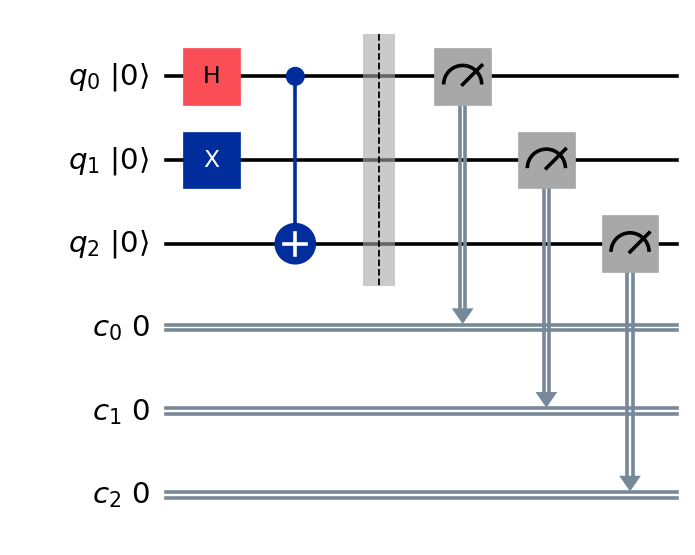

In [5]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt


# ============================================================
# 1. CRIAÇÃO DO OBJETO QUANTUMCIRCUIT
# ============================================================

# 3 qubits + 3 bits clássicos
qc = QuantumCircuit(3, 3)


# ============================================================
# 2. OPERAÇÕES QUÂNTICAS
# ============================================================

# Operações independentes
qc.h(0)
qc.x(1)

# Operação envolvendo dois qubits
qc.cx(0, 2)

# Separação visual entre processamento e medição
qc.barrier()


# ============================================================
# 3. MEDIÇÕES
# ============================================================

# Cada qubit é associado explicitamente
# ao bit clássico de mesmo índice.

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)


# ============================================================
# 4. VISUALIZAÇÃO DO CIRCUITO
# ============================================================

qc.draw(
    output="mpl",
    initial_state=True,
    cregbundle=False,
    fold=-1,
    scale=1.3
)

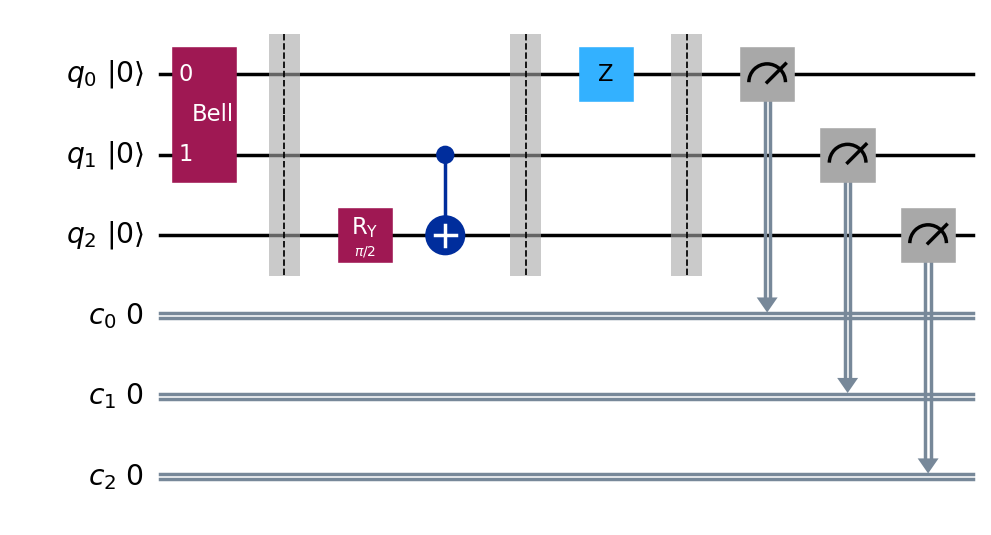

In [6]:
from math import pi

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import matplotlib.pyplot as plt


# ============================================================
# 1. PARÂMETRO SIMBÓLICO
# ============================================================

theta = Parameter("θ")


# ============================================================
# 2. PRIMEIRO BLOCO: PREPARAÇÃO DE BELL
# ============================================================

# O bloco é construído como um circuito independente.

bell = QuantumCircuit(2, name="Bell")

bell.h(0)
bell.cx(0, 1)


# Converte o circuito em uma porta reutilizável.
porta_bell = bell.to_gate(label="Bell")


# ============================================================
# 3. SEGUNDO BLOCO: TRANSFORMAÇÃO PARAMETRIZADA
# ============================================================

transformacao = QuantumCircuit(3, name="Transformação")

transformacao.ry(theta, 2)
transformacao.cx(1, 2)


# ============================================================
# 4. CIRCUITO PRINCIPAL
# ============================================================

qc = QuantumCircuit(3, 3)


# Insere o bloco Bell como uma única operação.
qc.append(porta_bell, [0, 1])

qc.barrier()


# ============================================================
# 5. COMPOSIÇÃO COM OUTRO CIRCUITO
# ============================================================

qc = qc.compose(transformacao)

qc.barrier()


# ============================================================
# 6. OPERAÇÃO FINAL
# ============================================================

qc.z(0)

qc.barrier()


# ============================================================
# 7. MEDIÇÕES
# ============================================================

qc.measure([0, 1, 2], [0, 1, 2])


# ============================================================
# 8. ATRIBUIÇÃO DE VALOR AO PARÂMETRO
# ============================================================

qc_final = qc.assign_parameters({
    theta: pi / 2
})


# ============================================================
# 9. VISUALIZAÇÃO MODULAR
# ============================================================

qc_final.draw(
    output="mpl",
    initial_state=True,
    cregbundle=False,
    fold=-1,
    scale=1.25
)

1. CIRCUITO QUÂNTICO


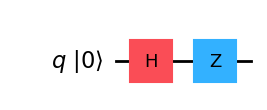


Estado preparado:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

2. Q-SPHERE


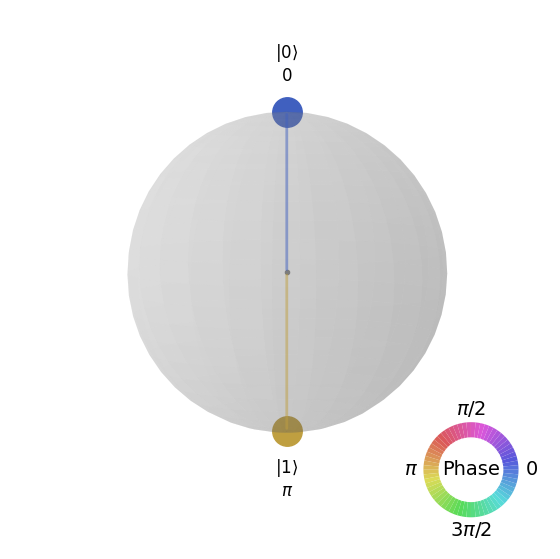


3. ESFERA DE BLOCH


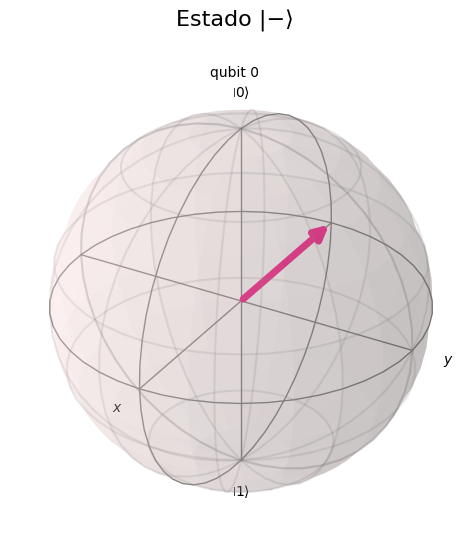


4. STATE CITY


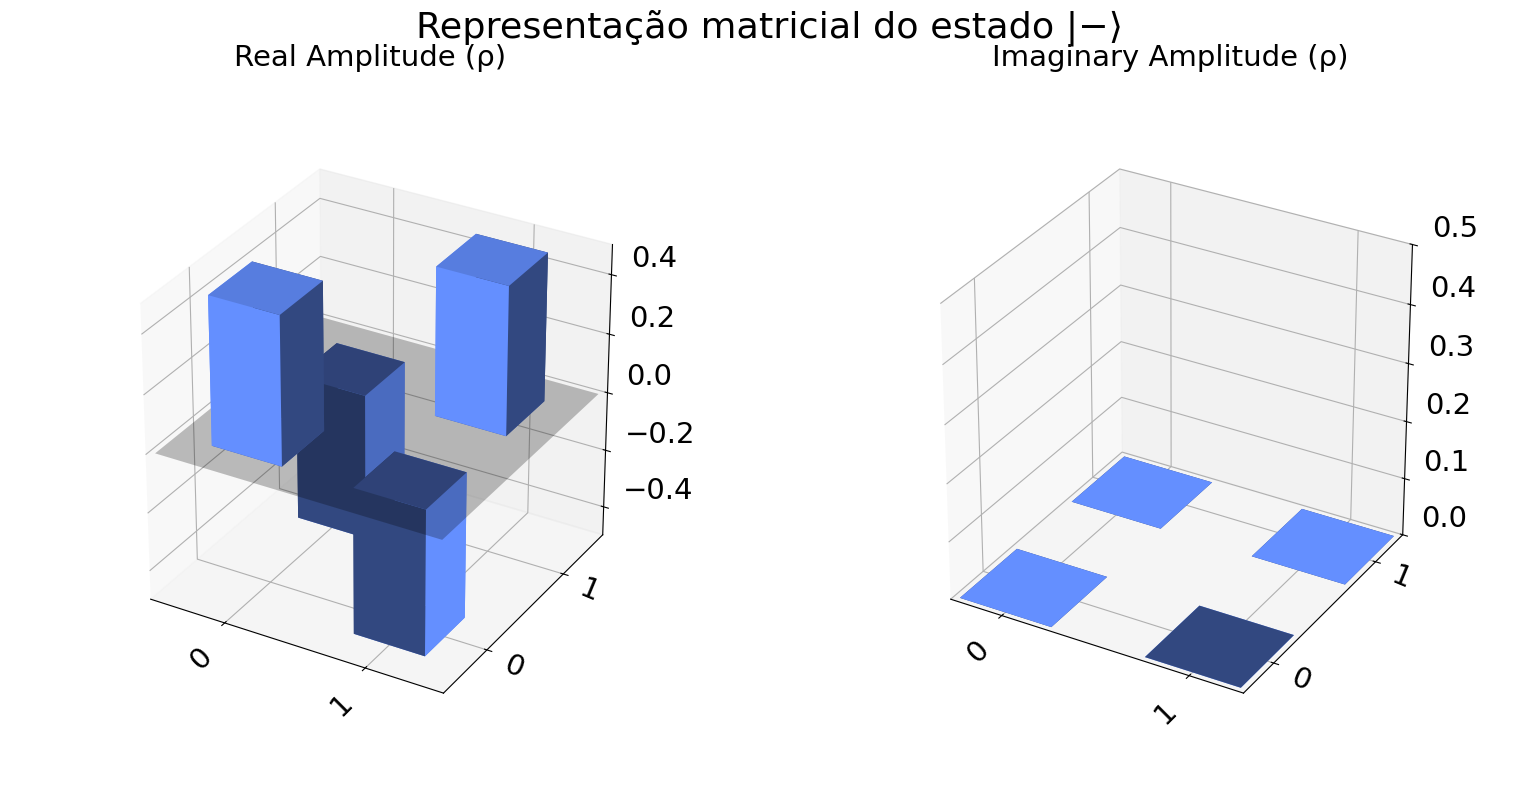


5. CIRCUITO COM MEDIÇÃO


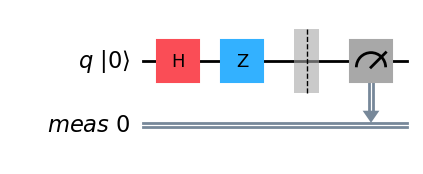


Contagens:
{'1': 499, '0': 525}

6. HISTOGRAMA DAS MEDIÇÕES


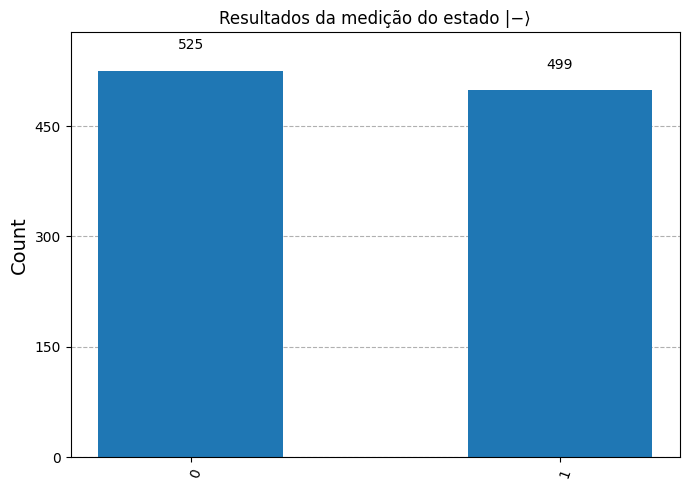

In [7]:
# ============================================================
# VISUALIZAÇÕES DE UM MESMO EXPERIMENTO QUÂNTICO
# ============================================================

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler

from qiskit.visualization import (
    plot_histogram,
    plot_state_qsphere,
    plot_bloch_multivector,
    plot_state_city
)

from IPython.display import display


# ============================================================
# 1. CONSTRUÇÃO DO CIRCUITO
# ============================================================

qc = QuantumCircuit(1)

# |0> -> |+>
qc.h(0)

# |+> -> |->
qc.z(0)


# ============================================================
# 2. VISUALIZAÇÃO 1 — CIRCUITO
# ============================================================

print("1. CIRCUITO QUÂNTICO")

display(
    qc.draw(
        output="mpl",
        initial_state=True,
        fold=-1
    )
)


# ============================================================
# 3. OBTENÇÃO DO ESTADO ANTES DA MEDIÇÃO
# ============================================================

estado = Statevector.from_instruction(qc)

print("\nEstado preparado:")
print(estado)


# ============================================================
# 4. VISUALIZAÇÃO 2 — Q-SPHERE
# ============================================================

print("\n2. Q-SPHERE")

display(
    plot_state_qsphere(
        estado,
        show_state_labels=True,
        show_state_phases=True
    )
)


# ============================================================
# 5. VISUALIZAÇÃO 3 — ESFERA DE BLOCH
# ============================================================

print("\n3. ESFERA DE BLOCH")

display(
    plot_bloch_multivector(
        estado,
        title="Estado |−⟩"
    )
)


# ============================================================
# 6. VISUALIZAÇÃO 4 — STATE CITY
# ============================================================

print("\n4. STATE CITY")

display(
    plot_state_city(
        estado,
        title="Representação matricial do estado |−⟩"
    )
)


# ============================================================
# 7. CRIAÇÃO DE UMA CÓPIA PARA MEDIÇÃO
# ============================================================

qc_medido = qc.copy()

qc_medido.measure_all()


# ============================================================
# 8. CIRCUITO COM MEDIÇÃO
# ============================================================

print("\n5. CIRCUITO COM MEDIÇÃO")

display(
    qc_medido.draw(
        output="mpl",
        initial_state=True,
        cregbundle=False,
        fold=-1
    )
)


# ============================================================
# 9. EXECUÇÃO DO CIRCUITO
# ============================================================

sampler = StatevectorSampler()

shots = 1024

resultado = sampler.run(
    [qc_medido],
    shots=shots
).result()

contagens = resultado[0].data.meas.get_counts()

print("\nContagens:")
print(contagens)


# ============================================================
# 10. VISUALIZAÇÃO 5 — HISTOGRAMA
# ============================================================

print("\n6. HISTOGRAMA DAS MEDIÇÕES")

display(
    plot_histogram(
        contagens,
        title="Resultados da medição do estado |−⟩",
        bar_labels=True,
        figsize=(7, 5)
    )
)